In [1]:
from ray_utils import load_data

df = load_data()
df.head()

C:\Users\dnts5\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-30 02:51:39,430	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-30 02:51:40,137	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-30 02:51:46,897	INFO worker.py:2003 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
C:\Users\dnts5\AppData\Local\Programs\Python\Python311\Lib\site-packages\ray\_private\worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To en

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [3]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


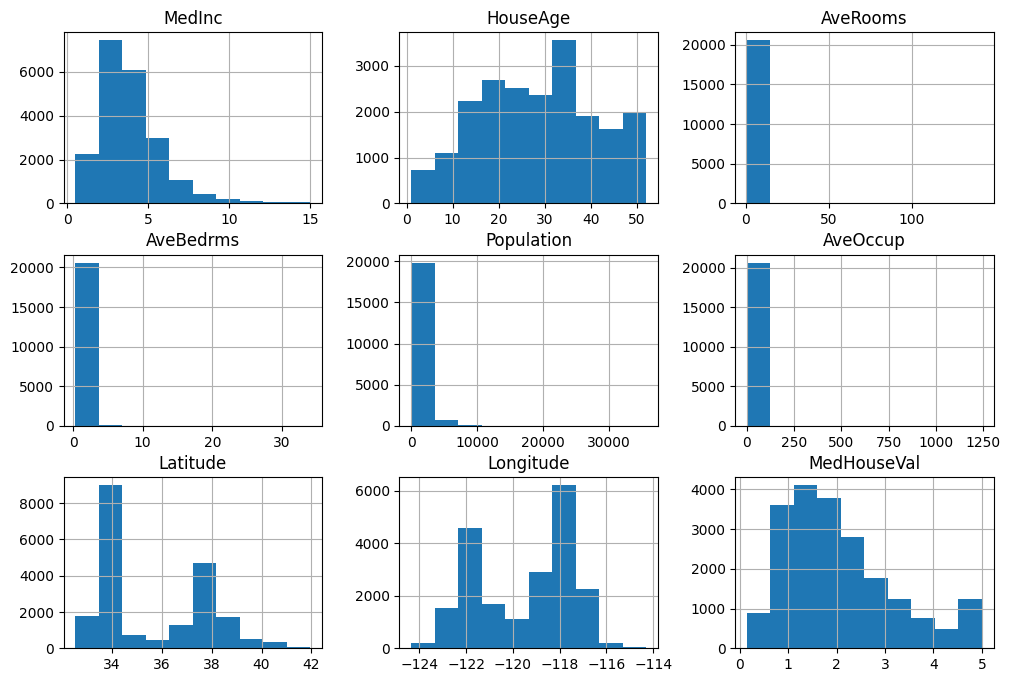

In [4]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.show()

In [5]:
df.corr()["MedHouseVal"].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [8]:
y_pred = model.predict(X_test)

In [9]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.5053399773665033
R2 Score: 0.8051230593157366


In [10]:
import ray

ray.init(ignore_reinit_error=True)

2026-04-30 02:52:30,680	INFO worker.py:1828 -- Calling ray.init() again after it has already been called.


Python version:,3.11.4
Ray version:,2.55.1
Dashboard:,http://127.0.0.1:8265


In [11]:
@ray.remote
def train_model(n_estimators):
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import mean_squared_error, r2_score
    
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    rmse = mean_squared_error(y_test, preds, squared=False)
    r2 = r2_score(y_test, preds)
    
    return {"n_estimators": n_estimators, "rmse": rmse, "r2": r2}

In [12]:
results = ray.get([
    train_model.remote(50),
    train_model.remote(100),
    train_model.remote(200)
])

results

[{'n_estimators': 50, 'rmse': 0.5072454330767726, 'r2': 0.8036506665860602},
 {'n_estimators': 100, 'rmse': 0.5053399773665033, 'r2': 0.8051230593157366},
 {'n_estimators': 200, 'rmse': 0.5039602414072009, 'r2': 0.8061857564039718}]

In [13]:
from ray import tune
from ray.air import session

In [14]:
def train_tune(config):
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import mean_squared_error
    from ray.air import session

    model = RandomForestRegressor(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = mean_squared_error(y_test, preds, squared=False)

    session.report({"rmse": rmse})

In [15]:
analysis = tune.run(
    train_tune,
    config={
        "n_estimators": tune.choice([50, 100, 200]),
        "max_depth": tune.choice([5, 10, 20])
    },
    num_samples=6
)

2026-04-30 02:53:57,740	INFO tune.py:615 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949


(raylet) Stack (most recent call first):
(raylet)   File "C:\Users\dnts5\AppData\Local\Programs\Python\Python311\Lib\site-packages\ray\_private\worker.py", line 628 in job_logging_config
(raylet)   File "C:\Users\dnts5\AppData\Local\Programs\Python\Python311\Lib\site-packages\ray\_private\worker.py", line 2801 in disconnect
(raylet)   File "C:\Users\dnts5\AppData\Local\Programs\Python\Python311\Lib\site-packages\ray\_private\worker.py", line 2132 in shutdown
(raylet)   File "C:\Users\dnts5\AppData\Local\Programs\Python\Python311\Lib\site-packages\ray\_private\worker.py", line 1143 in wrapper


Trial name,rmse
train_tune_5c60f_00000,0.505833
train_tune_5c60f_00001,0.543266
train_tune_5c60f_00002,0.680254
train_tune_5c60f_00003,0.680254
train_tune_5c60f_00004,0.504571
train_tune_5c60f_00005,0.545151


(train_tune pid=3308) C:\Users\dnts5\AppData\Local\Programs\Python\Python311\Lib\site-packages\ray\train\_internal\session.py:791: RayDeprecationWarning: `ray.train.report` should be switched to `ray.tune.report` when running in a function passed to Ray Tune. This will be an error in the future. See this issue for more context: https://github.com/ray-project/ray/issues/49454
(train_tune pid=3308)   _log_deprecation_warning(
(raylet) Stack (most recent call first): [repeated 3x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(raylet)   File "C:\Users\dnts5\AppData\Local\Programs\Python\Python311\Lib\site-packages\ray\_private\worker.py", line 628 in job_logging_config [repeated 3x across cluster]
(raylet)   File "C:\Users\dnts5\AppData\Local\Programs\Python\Python311\Lib\site-packages\ray\_private\worker.py",

In [16]:
analysis.get_best_config(metric="rmse", mode="min")

{'n_estimators': 200, 'max_depth': 20}

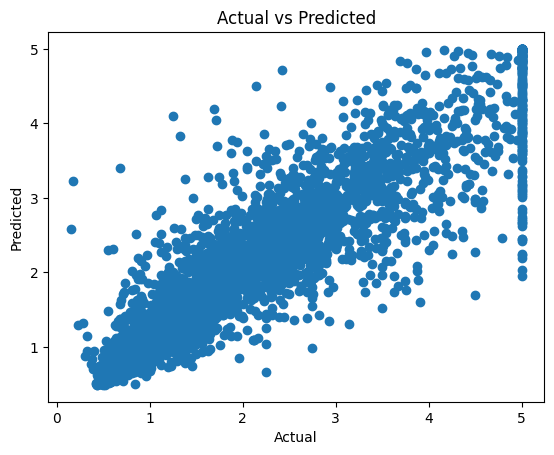

In [17]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [18]:
from ray import serve
serve.start(detached=True)

(ProxyActor pid=5708) INFO 2026-04-30 02:55:26,659 proxy 127.0.0.1 -- Proxy starting on node 332d7021235ef6f1e66fc788e0b91190a4adf9dd24d1caf1c1508625 (HTTP port: 8000).
(ProxyActor pid=5708) INFO 2026-04-30 02:55:26,837 proxy 127.0.0.1 -- Got updated endpoints: {}.
INFO 2026-04-30 02:55:26,844 serve 23860 -- Started Serve in namespace "serve".


In [25]:
from ray import serve

@serve.deployment
class HousingModel:
    def __init__(self):
        self.model = model

    async def __call__(self, request):
        import numpy as np

        data = await request.json()

        features = np.array(data["features"]).reshape(1, -1)
        prediction = self.model.predict(features)

        return {"prediction": float(prediction[0])}

# run deployment
serve.run(HousingModel.bind())

INFO 2026-04-30 03:02:09,547 serve 23860 -- Connecting to existing Serve app in namespace "serve". New http options will not be applied.
(ServeController pid=33628) INFO 2026-04-30 03:02:10,906 controller 33628 -- Deploying new version of Deployment(name='HousingModel', app='default') (initial target replicas: 1).
(ServeController pid=33628) INFO 2026-04-30 03:02:12,187 controller 33628 -- Stopping 1 replicas of Deployment(name='HousingModel', app='default') with outdated versions.
(ServeController pid=33628) INFO 2026-04-30 03:02:12,189 controller 33628 -- Adding 1 replica to Deployment(name='HousingModel', app='default').
(ServeController pid=33628) INFO 2026-04-30 03:02:14,291 controller 33628 -- Replica(id='x561nnqt', deployment='HousingModel', app='default') is stopped.
INFO 2026-04-30 03:02:15,097 serve 23860 -- Application 'default' is ready at http://127.0.0.1:8000/.


DeploymentHandle(deployment='HousingModel')

In [26]:
import requests

sample = X_test.iloc[0].tolist()

response = requests.post(
    "http://127.0.0.1:8000/",
    json={"features": sample}
)

print(response.text)

{"prediction":0.5094999999999998}


(ServeReplica:default:HousingModel pid=27468) C:\Users\dnts5\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
(ServeReplica:default:HousingModel pid=27468)   warnings.warn(
(ServeReplica:default:HousingModel pid=27468) INFO 2026-04-30 03:03:33,631 default_HousingModel ks9thrho 81c13975-9f6e-4413-b9ea-4389e00414af -- POST / 200 24.8ms
